Using: cuda
Epoch 1 | Train: 0.7855 | Test: 0.8061
Epoch 2 | Train: 0.8963 | Test: 0.8397
Epoch 3 | Train: 0.9151 | Test: 0.8397
Epoch 4 | Train: 0.9160 | Test: 0.8670
Epoch 5 | Train: 0.9266 | Test: 0.8766
Epoch 6 | Train: 0.9287 | Test: 0.8782
Epoch 7 | Train: 0.9247 | Test: 0.8798
Epoch 8 | Train: 0.9360 | Test: 0.8766
Epoch 9 | Train: 0.9277 | Test: 0.8766
Epoch 10 | Train: 0.9293 | Test: 0.8766
Epoch 11 | Train: 0.9373 | Test: 0.8846
Epoch 12 | Train: 0.9404 | Test: 0.8798
Epoch 13 | Train: 0.9302 | Test: 0.8782
Epoch 14 | Train: 0.9308 | Test: 0.8798
Epoch 15 | Train: 0.9373 | Test: 0.8766
Early stopping triggered
Best Test Accuracy: 0.8846153846153846


/tmp/ipykernel_4117/1273550970.py:162: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


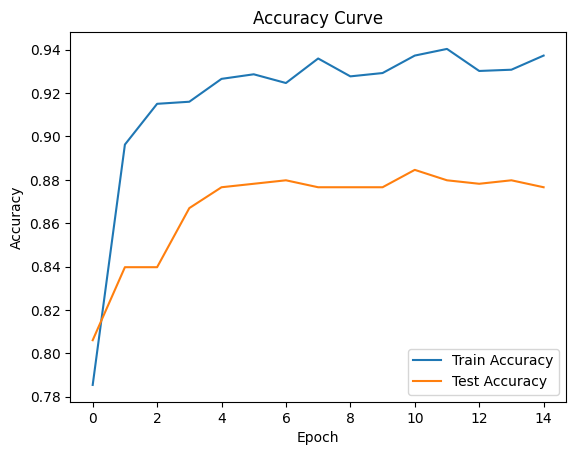

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# DEVICE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# -----------------------------
# SETTINGS
# -----------------------------
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 20

# -----------------------------
# TRANSFORMS
# -----------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# -----------------------------
# DATA
# -----------------------------
train_data = datasets.ImageFolder("xray/train", transform=train_transform)
test_data = datasets.ImageFolder("xray/test", transform=test_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, num_workers=4)

# -----------------------------
# CLASS WEIGHT (IMPORTANT)
# -----------------------------
targets = np.array(train_data.targets)
class_counts = np.bincount(targets)
pos_weight = torch.tensor(class_counts[0] / class_counts[1]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# -----------------------------
# MODEL (EFFICIENTNET)
# -----------------------------
model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Sequential(
    nn.Linear(model.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
)

model = model.to(device)

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)

# LR scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.3, patience=2
)

# -----------------------------
# TRACKING
# -----------------------------
train_acc_hist = []
test_acc_hist = []

best_acc = 0
patience = 4
counter = 0

# -----------------------------
# TRAIN
# -----------------------------
for epoch in range(EPOCHS):
    model.train()
    correct, total = 0, 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = torch.sigmoid(outputs) > 0.5
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # TEST DURING TRAINING
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total

    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc)

    print(f"Epoch {epoch+1} | Train: {train_acc:.4f} | Test: {test_acc:.4f}")

    scheduler.step(test_acc)

    # Save best
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

# -----------------------------
# FINAL RESULT
# -----------------------------
print("Best Test Accuracy:", best_acc)

# -----------------------------
# LOAD BEST MODEL
# -----------------------------
model.load_state_dict(torch.load("best_model.pth"))

# -----------------------------
# SAVE FINAL MODEL
# -----------------------------
torch.save(model.state_dict(), "backend/pneumonia_efficientnet.pth")

# -----------------------------
# PLOT GRAPH
# -----------------------------
plt.figure()
plt.plot(train_acc_hist, label="Train Accuracy")
plt.plot(test_acc_hist, label="Test Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()